# Combining TIme-Reverse (TRV) and Time-Forward (TFWD) Simulations

In this Tutorial, we will be combining the results produced from both time-forward and time-reverse simulations in the past two tutorials. 

First we will write some basic functions to extract the field datasets.

In [1]:
# Importing various Python libraries and MeepSAT modules
import sys
import os
import site
from pathlib import Path
import meep as mp
import numpy as np
import h5py
import matplotlib.pyplot as plt
import time
import json
import math

# Importing the MEEPSAT librarires
import meepsat.simulator as sim
import meepsat.meep_geometry as comp_meep
import meepsat.permittivity_components as comp_eps
import meepsat.stepfunctions as stepfunctions
import meepsat.json_to_script as json_to_script
import meepsat.field_analysis as mpsat_analysis
import meepsat.helpers as mpsat_helpers

Using MPI version 4.1, 1 processes


# Far Field Profiles Comparision

Below we will compare the far field beams from the TRV simulations done for the three forebaffle cases

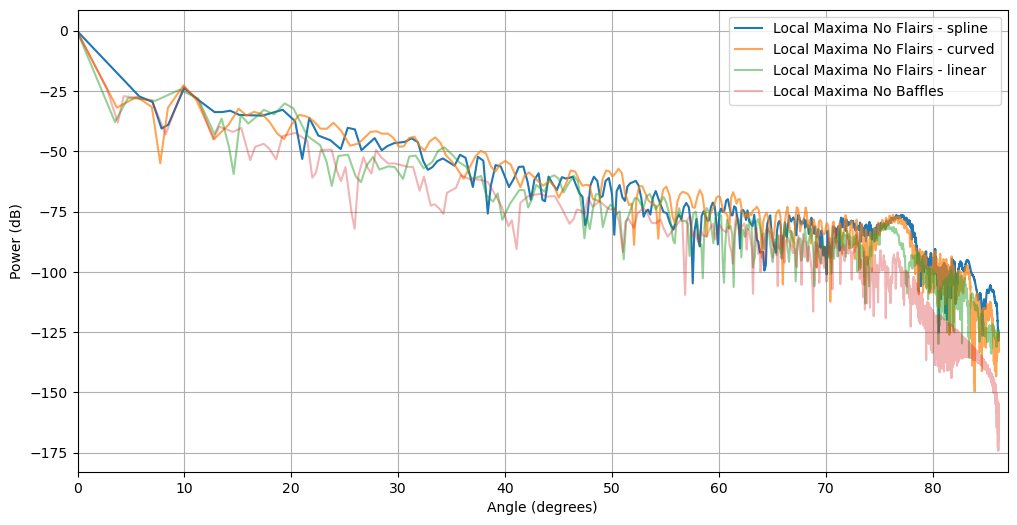

In [2]:
import numpy as np

def load_farfield_data(npz_path, label):
    """
    Load far-field data from an .npz file.

    Parameters
    ----------
    npz_path : str or Path
        Path to the .npz file.

    Returns
    -------
    angle : np.ndarray
        Angle array.
    power_dB : np.ndarray
        Power (dB) array.
    plot_label : str
        Label for plotting.
    """
    data = np.load(npz_path, allow_pickle=True)
    spline = data[label].item()

    angle = spline["angle"]
    power_dB = spline["power_dB"]
    plot_label = spline["plot_label"]

    return {"angle": angle, "power_dB": power_dB, "plot_label": plot_label}

import numpy as np
from scipy.signal import find_peaks, savgol_filter


def find_local_maxima(
    power_dB,
    angle,
    apply_smoothing=False,
    smooth_window=301,
    polyorder=3,
    split_angle=50.0,
    near_prominence=2.0,
    far_prominence=5.0,
    near_distance_deg=0.2,
    far_distance_deg=1.0,
):
    """
    Find local maxima in a radiation pattern using angle-dependent
    peak detection criteria.

    Parameters
    ----------
    power_dB : np.ndarray
        Power (dB) array.
    angle : np.ndarray
        Angle array (degrees).
    apply_smoothing : bool, optional
        Apply Savitzky-Golay smoothing before peak detection.
    smooth_window : int, optional
        Savitzky-Golay window length (must be odd).
    polyorder : int, optional
        Polynomial order for Savitzky-Golay filter.
    split_angle : float, optional
        Angle (degrees) separating near- and far-angle peak detection.
    near_prominence : float, optional
        Peak prominence before split_angle.
    far_prominence : float, optional
        Peak prominence after split_angle.
    near_distance_deg : float, optional
        Minimum angular separation (degrees) before split_angle.
    far_distance_deg : float, optional
        Minimum angular separation (degrees) after split_angle.

    Returns
    -------
    peak_angles : np.ndarray
    peak_power : np.ndarray
    """

    # # Optional smoothing
    # if apply_smoothing:
    #     power_linear = 10 ** (power_dB / 10)

    #     if smooth_window >= len(power_linear):
    #         smooth_window = len(power_linear) - 1
    #     if smooth_window % 2 == 0:
    #         smooth_window -= 1

    #     power_linear = savgol_filter(
    #         power_linear,
    #         window_length=smooth_window,
    #         polyorder=polyorder,
    #         mode="interp",
    #     )

    #     power_linear = np.maximum(power_linear, 1e-30)
    #     data_to_use = 10 * np.log10(power_linear)

    # else:
    #     data_to_use = power_dB

    # # Convert angular distances (degrees) to samples
    # resolution = np.mean(np.diff(angle))  # degrees/sample
    # near_distance = max(1, int(round(near_distance_deg / resolution)))
    # far_distance = max(1, int(round(far_distance_deg / resolution)))

    # # Split the data
    # split_idx = np.searchsorted(angle, split_angle)

    # # Detect peaks in the near-angle region
    # peaks_near, _ = find_peaks(
    #     data_to_use[:split_idx],
    #     prominence=near_prominence,
    #     distance=near_distance,
    # )

    # # Detect peaks in the far-angle region
    # peaks_far, _ = find_peaks(
    #     data_to_use[split_idx:],
    #     prominence=far_prominence,
    #     distance=far_distance,
    # )

    # # Convert far indices back to global indices
    # peaks_far += split_idx

    # # Combine and sort
    # peaks = np.sort(np.concatenate((peaks_near, peaks_far)))

    # return angle[peaks], power_dB[peaks]
    
        
    # Find local maxima only
    peaks, _ = find_peaks(
        power_dB,
        prominence=3, 
        distance=3
    )

    peak_angles = angle[peaks]
    peak_power = power_dB[peaks]

    return peak_angles, peak_power
    
    

trv_no_flairs_path = '/Users/asheshak_oaslak/Phd_work/MeepSAT/processed_data/simple_single_lens_AddedComplexities_TRV_b_noflairs/0.5003461427972281GHz/far_field_results.npz'
trv_with_flairs_path = '/Users/asheshak_oaslak/Phd_work/MeepSAT/processed_data/simple_single_lens_AddedComplexities_TRV_b_withflairs/0.5003461427972281GHz/far_field_results.npz'
trv_no_baffles_path = '/Users/asheshak_oaslak/Phd_work/MeepSAT/processed_data/simple_single_lens_AddedComplexities_TRV_b_nobaffles/0.5003461427972281GHz/far_field_results.npz'

# # Load the far-field results from the .npz files
# trv_no_flairs_data = np.load(trv_no_flairs_path, allow_pickle=True)
# trv_with_flairs_data = np.load(trv_with_flairs_path, allow_pickle=True)
# trv_no_baffles_data = np.load(trv_no_baffles_path, allow_pickle=True)

# # Extract the far-field data for each case
label_fb_config = ['spline', 'curved', 'linear']

plt.style.use('default')
plt.figure(figsize=(12, 6))

alpha = 1  # Transparency for the plots

# Plot the no baffles case for comparison
no_baffles_data = load_farfield_data(trv_no_baffles_path, '_nobaffle')
power_dB_no_baffles = no_baffles_data['power_dB']
angle_no_baffles = no_baffles_data['angle']
peak_angles_no_baffles, peak_power_no_baffles = find_local_maxima(power_dB_no_baffles, angle_no_baffles, apply_smoothing=False)

# Function to calculate the moving average
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')
wss = 5
for i, label in enumerate(label_fb_config):
    # No Flairs
    no_flairs_data = load_farfield_data(trv_no_flairs_path, label)
    power_dB_no_flairs = no_flairs_data['power_dB']
    angle_no_flairs = no_flairs_data['angle']
    peak_angles_no_flairs, peak_power_no_flairs = find_local_maxima(power_dB_no_flairs, angle_no_flairs, apply_smoothing=False)

    # With Flairs
    with_flairs_data = load_farfield_data(trv_with_flairs_path, label)
    power_dB_with_flairs = with_flairs_data['power_dB']
    angle_with_flairs = with_flairs_data['angle']
    peak_angles_with_flairs, peak_power_with_flairs = find_local_maxima(power_dB_with_flairs, angle_with_flairs, apply_smoothing=False)
    
    # # Plot the far-field patterns for each configuration
    # plt.plot(angle_no_flairs, power_dB_no_flairs, label=f'No Flairs - {label}', linestyle='--', alpha=alpha)
    # plt.plot(angle_with_flairs, power_dB_with_flairs, label=f'With Flairs - {label}', linestyle='-', alpha=alpha)

    
    # plot the moving average of the far-field patterns for each configuration
    window_size = wss  # Adjust the window size as needed
    smoothed_no_flairs = moving_average(power_dB_no_flairs, window_size)
    smoothed_with_flairs = moving_average(power_dB_with_flairs, window_size)
    
    # Find the local maxima of the smoothed data
    peak_angles_no_flairs_smoothed, peak_power_no_flairs_smoothed = find_local_maxima(smoothed_no_flairs, angle_no_flairs[:len(smoothed_no_flairs)], apply_smoothing=False)
    peak_angles_with_flairs_smoothed, peak_power_with_flairs_smoothed = find_local_maxima(smoothed_with_flairs, angle_with_flairs[:len(smoothed_with_flairs)], apply_smoothing=False)
    
    # plt.plot(angle_no_flairs[:len(smoothed_no_flairs)], smoothed_no_flairs, label=f'Smoothed No Flairs - {label}', linestyle='--', alpha=alpha)
    # plt.plot(angle_with_flairs[:len(smoothed_with_flairs)], smoothed_with_flairs, label=f'Smoothed With Flairs - {label}', linestyle='-', alpha=alpha)

    # Plot the local maxima of the smoothed data
    plt.plot(peak_angles_no_flairs_smoothed, peak_power_no_flairs_smoothed, label=f'Local Maxima No Flairs - {label}', alpha=alpha)
    # plt.plot(peak_angles_with_flairs_smoothed, peak_power_with_flairs_smoothed, label=f'Local Maxima With Flairs - {label}', alpha=alpha)
    
    # Plot the local maxima for each configuration
    # Normalise to the no baffles case for comparison
    # plt.plot(peak_angles_no_flairs, peak_power_no_flairs, label=f'No Flairs - {label}')
    # plt.plot(peak_angles_with_flairs, peak_power_with_flairs, label=f'With Flairs - {label}')
    
    # Pass the loop after one case
    # break
    alpha *= 0.7  # Reduce transparency for subsequent plots
    

# Plot the far-field pattern for the no baffles case
# plt.plot(angle_no_baffles, power_dB_no_baffles, label=f'No Baffles', linestyle='-', alpha=alpha)

# # Plot the local maxima for the no baffles case
# plt.plot(peak_angles_no_baffles, peak_power_no_baffles, label=f'No Baffles')

# Plot the moving average of the far-field pattern for the no baffles case
window_size = wss  # Adjust the window size as needed
smoothed_no_baffles = moving_average(power_dB_no_baffles, window_size)
# Find the local maxima of the smoothed data for the no baffles case
peak_angles_no_baffles_smoothed, peak_power_no_baffles_smoothed = find_local_maxima(smoothed_no_baffles, angle_no_baffles[:len(smoothed_no_baffles)], apply_smoothing=False)

# Plot the smoothed far-field pattern for the no baffles case
# plt.plot(angle_no_baffles[:len(smoothed_no_baffles)], smoothed_no_baffles, label=f'Smoothed No Baffles', linestyle='-', alpha=alpha)

# Plot the local maxima of the smoothed data for the no baffles case
plt.plot(peak_angles_no_baffles_smoothed, peak_power_no_baffles_smoothed, label=f'Local Maxima No Baffles', alpha=alpha)

plt.xlabel('Angle (degrees)')
plt.ylabel('Power (dB)')
# plt.title('Far-Field Patterns')
plt.xlim(0, 87)
# plt.ylim(-120,0)
plt.legend()
plt.grid(True)
plt.show()


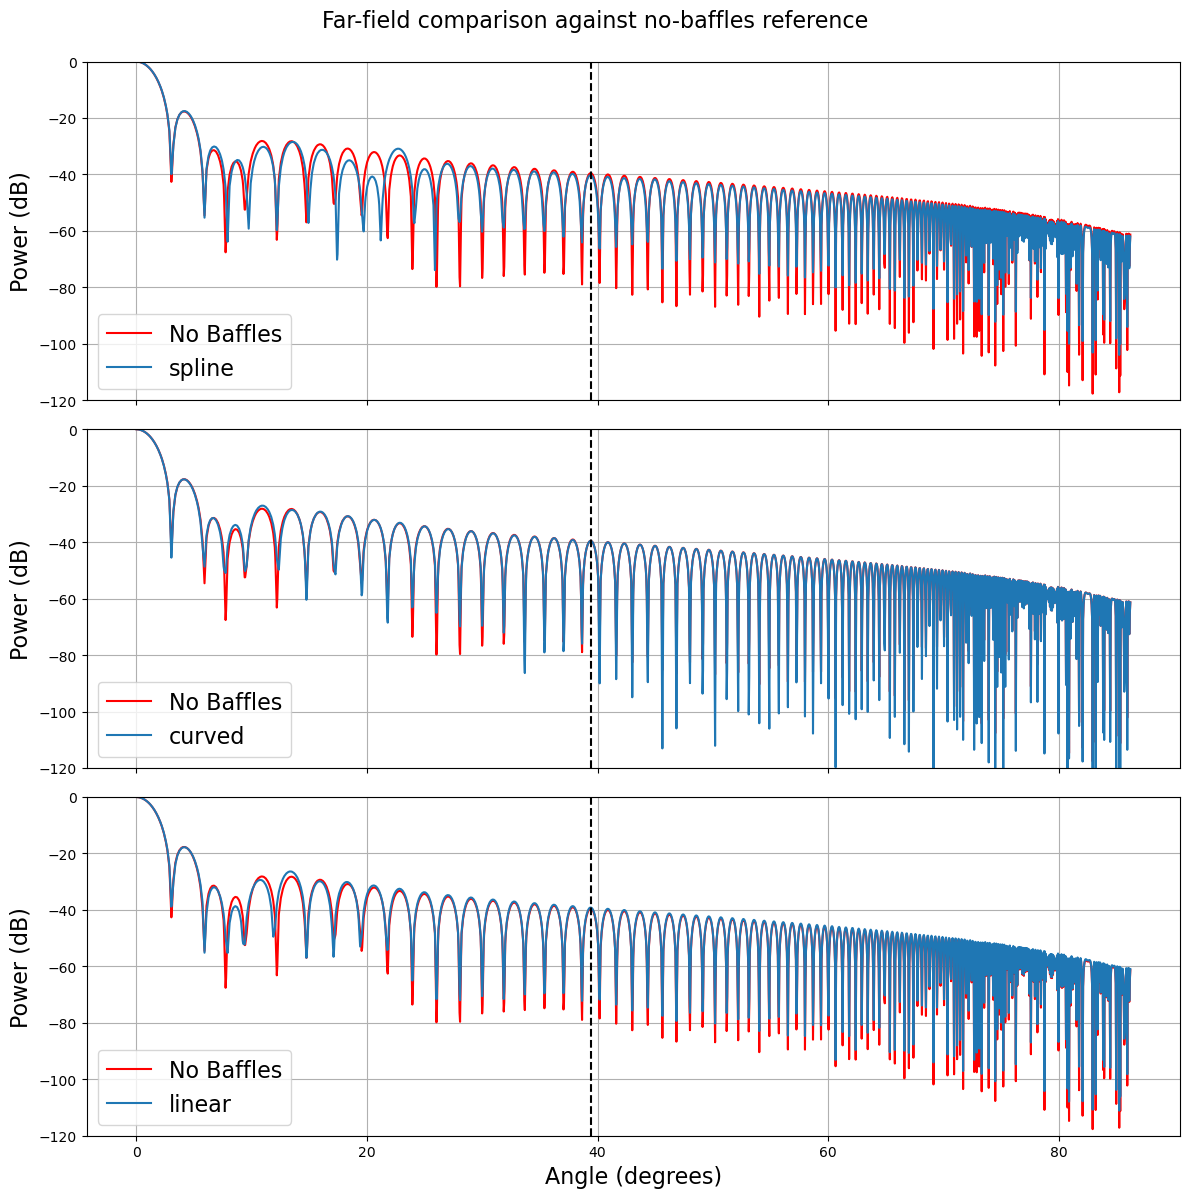

[{'configuration': 'spline',
  'rms_error_dB': np.float64(4.8283827994817194),
  'mae_dB': np.float64(2.515873669873553),
  'iae_dB_deg': np.float64(216.89540202023653),
  'peak_angle_deg': np.float64(0.0),
  'peak_power_dB': np.float64(0.0),
  'sidelobe_angle_deg': np.float64(4.221610805402701),
  'sidelobe_power_dB': np.float64(-17.56999730750766),
  'sidelobe_margin_dB': np.float64(-17.56999730750766)},
 {'configuration': 'curved',
  'rms_error_dB': np.float64(3.2763756165759768),
  'mae_dB': np.float64(1.045775342000172),
  'iae_dB_deg': np.float64(90.16238586655265),
  'peak_angle_deg': np.float64(0.0),
  'peak_power_dB': np.float64(0.0),
  'sidelobe_angle_deg': np.float64(4.091045522761381),
  'sidelobe_power_dB': np.float64(-17.747310952693688),
  'sidelobe_margin_dB': np.float64(-17.747310952693688)},
 {'configuration': 'linear',
  'rms_error_dB': np.float64(2.257435058103564),
  'mae_dB': np.float64(1.1381762011367966),
  'iae_dB_deg': np.float64(98.12151403159491),
  'peak_an

In [3]:
import numpy as np
from scipy.interpolate import interp1d
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
# Set the fontsize of labels and ticks
plt.rcParams.update({'font.size': 20})

def load_farfield_data(npz_path, label):
    """
    Load far-field data from an .npz file.

    Parameters
    ----------
    npz_path : str or Path
        Path to the .npz file.
    label : str
        Key inside the npz file.

    Returns
    -------
    dict
        Dictionary with angle, power_dB, and plot_label.
    """
    data = np.load(npz_path, allow_pickle=True)
    entry = data[label].item()
    return {
        "angle": np.asarray(entry["angle"]),
        "power_dB": np.asarray(entry["power_dB"]),
        "plot_label": entry.get("plot_label", label),
    }


def compare_farfield_patterns(reference_data, candidate_data, angle_min=0.0, angle_max=87.0, npts=2000, sidelobe_prominence=1.0):
    """
    Compare two far-field patterns on a common angle grid.

    Returns a dictionary with a normalized RMS error, integrated absolute error,
    and sidelobe metrics.
    """
    ref_angle = np.asarray(reference_data["angle"])
    ref_power = np.asarray(reference_data["power_dB"])
    cand_angle = np.asarray(candidate_data["angle"])
    cand_power = np.asarray(candidate_data["power_dB"])

    common_angle = np.linspace(angle_min, angle_max, npts)

    ref_interp = interp1d(ref_angle, ref_power, bounds_error=False, fill_value=np.nan)
    cand_interp = interp1d(cand_angle, cand_power, bounds_error=False, fill_value=np.nan)

    ref_common = ref_interp(common_angle)
    cand_common = cand_interp(common_angle)
    valid = np.isfinite(ref_common) & np.isfinite(cand_common)

    ref_common = ref_common[valid]
    cand_common = cand_common[valid]
    common_angle = common_angle[valid]

    diff = cand_common - ref_common
    rms_error = np.sqrt(np.mean(diff**2))
    mae = np.mean(np.abs(diff))
    iae = np.trapezoid(np.abs(diff), common_angle)

    ref_peak_idx = np.argmax(ref_common)
    ref_peak_angle = common_angle[ref_peak_idx]
    ref_peak_power = ref_common[ref_peak_idx]

    cand_peak_idx = np.argmax(cand_common)
    cand_peak_angle = common_angle[cand_peak_idx]
    cand_peak_power = cand_common[cand_peak_idx]

    # First sidelobe estimate: first local maximum after the first valley following the main peak.
    # This avoids counting the shoulder of the main lobe as a sidelobe.
    sidelobe_level = np.nan
    sidelobe_angle = np.nan
    peak_offset = cand_peak_idx + 1
    if peak_offset < len(cand_common):
        minima_after_peak, _ = find_peaks(-cand_common[peak_offset:], distance=3)
        if len(minima_after_peak) > 0:
            first_null_idx = peak_offset + minima_after_peak[0]
        else:
            # Fallback when no clear valley is present.
            first_null_idx = np.searchsorted(common_angle, cand_peak_angle + 2.0)

        if first_null_idx < len(cand_common) - 1:
            sidelobe_region = cand_common[first_null_idx + 1:]
            sidelobe_region_angles = common_angle[first_null_idx + 1:]
            peaks, _ = find_peaks(sidelobe_region, prominence=sidelobe_prominence, distance=3)
            if len(peaks) > 0:
                first_peak = peaks[0]
                sidelobe_level = sidelobe_region[first_peak]
                sidelobe_angle = sidelobe_region_angles[first_peak]

    return {
        "angle": common_angle,
        "reference": ref_common,
        "candidate": cand_common,
        "diff": diff,
        "rms_error": rms_error,
        "mae": mae,
        "iae": iae,
        "reference_peak_angle": ref_peak_angle,
        "reference_peak_power": ref_peak_power,
        "candidate_peak_angle": cand_peak_angle,
        "candidate_peak_power": cand_peak_power,
        "candidate_sidelobe_angle": sidelobe_angle,
        "candidate_sidelobe_power": sidelobe_level,
    }


trv_no_flairs_path = '/Users/asheshak_oaslak/Phd_work/MeepSAT/processed_data/simple_single_lens_AddedComplexities_TRV_b_noflairs/0.5003461427972281GHz/far_field_results.npz'
trv_no_baffles_path = '/Users/asheshak_oaslak/Phd_work/MeepSAT/processed_data/simple_single_lens_AddedComplexities_TRV_b_nobaffles/0.5003461427972281GHz/far_field_results.npz'

label_fb_config = ['spline', 'curved', 'linear']
reference_label = '_nobaffle'

plt.style.use('default')
fig, axes = plt.subplots(len(label_fb_config), 1, figsize=(12, 12), sharex=True)
metric_rows = []

for ax, label in zip(axes, label_fb_config):
    candidate_data = load_farfield_data(trv_no_flairs_path, label)
    reference_data = load_farfield_data(trv_no_baffles_path, reference_label)

    comparison = compare_farfield_patterns(reference_data, candidate_data, angle_min=0.0, angle_max=87.0)

    ax.plot(comparison["angle"], comparison["reference"], label='No Baffles', color='red', linewidth=1.5)
    ax.plot(comparison["angle"], comparison["candidate"], label=f'{label}', linewidth=1.5)
    ax.set_ylabel('Power (dB)', fontsize=16)
    # draw a vertical line at angle = 39.387
    ax.axvline(x=39.387, color='black', linestyle='--')#, label='Angle between far edges of pupil aperture and baffle')
    
    ax.set_ylim(-120, 0)
    ax.grid(True)
    ax.legend(loc='lower left', fontsize=16)

    metric_rows.append({
        'configuration': label,
        'rms_error_dB': comparison['rms_error'],
        'mae_dB': comparison['mae'],
        'iae_dB_deg': comparison['iae'],
        'peak_angle_deg': comparison['candidate_peak_angle'],
        'peak_power_dB': comparison['candidate_peak_power'],
        'sidelobe_angle_deg': comparison['candidate_sidelobe_angle'],
        'sidelobe_power_dB': comparison['candidate_sidelobe_power'],
        'sidelobe_margin_dB': comparison['candidate_sidelobe_power'] - comparison['candidate_peak_power'],
    })

axes[-1].set_xlabel('Angle (degrees)', fontsize=16)
fig.suptitle('Far-field comparison against no-baffles reference', y=0.995, fontsize=16)
plt.tight_layout()
plt.show()

comparison_table = metric_rows
comparison_table

In [ ]:
def load_fields(basepath, filename):
    """Load a field stored in an .npz file."""
    filepath = os.path.join(basepath, filename)
    return np.load(filepath)


def load_simulation_data(json_data, forebaffle_configs, savepath_dir):
    """
    Analyze all forebaffle configurations.

    Parameters
    ----------
    data : dict
        Simulation JSON input data.
    forebaffle_configs : list
        List of forebaffle configurations.
    savepath_dir : str
        Directory containing the simulation outputs.

    Returns
    -------
    list
        List of dictionaries containing the computed fields for each configuration.
    """
    results = []

    for i, config in enumerate(forebaffle_configs):
        print(f"\n{'=' * 50}")
        print(f"Analysing simulation {i + 1}/{len(forebaffle_configs)}", "Config:", config)
        print(f"{'=' * 50}\n")

        # Load the simulation data for the current configuration
        with open(json_data, 'r') as f:
            sim_data = json.load(f)
        sim_data["simulation"]["name"] += f"_config_{i}"

        savepath = os.path.join(savepath_dir, f"config_{i}")

        # Load field data
        e_data = load_fields(savepath, "efield_timeavg.npz")
        h_data = load_fields(savepath, "hfield_timeavg.npz")
        xyzw_data = load_fields(savepath, "xyzw.npz")

        print("E-field data keys:", e_data.files)
        print("H-field data keys:", h_data.files)
        print("XYZW data keys:", xyzw_data.files)

        # TE components
        ez = e_data["ez_real"] + 1j * e_data["ez_imag"]
        hx = h_data["hx_real"] + 1j * h_data["hx_imag"]
        hy = h_data["hy_real"] + 1j * h_data["hy_imag"]

        # Poynting vector
        sx = -ez * np.conj(hy)
        sy = ez * np.conj(hx)

        sx_mag = np.abs(sx)
        sy_mag = np.abs(sy)
        s_total = np.sqrt(sx_mag**2 + sy_mag**2)
        s_total_db = 10 * np.log10(s_total / np.max(s_total) + 1e-20)

        # E-field power
        ez_power = np.abs(ez) ** 2
        ez_power_db = 10 * np.log10(ez_power / np.max(ez_power) + 1e-20)

        results.append({
            "config": config,
            "sim_data": sim_data,
            "xyzw": xyzw_data,
            "ez": ez,
            "hx": hx,
            "hy": hy,
            "sx": sx,
            "sy": sy,
            "s_total": s_total,
            "s_total_db": s_total_db,
            "ez_power": ez_power,
            "ez_power_db": ez_power_db,
        })

    return results



In [ ]:
# Some universal constants
c_mm_s = 299792458.0 * 1000.0  # Speed of light in mm/s (m/s -> mm/s)
# Frequency of the simulation
freq = 150.0  # Frequency in GHz
a = 1  # 1 meep unit = 1 mm  
wvl = c_mm_s / (freq * 1e9)  # Wavelength in mm
freq_meep = 1.0 / (wvl * a)
print("freq (meep units):", freq_meep)
freq = freq_meep

# Savepath directories
# NO FLAIRS
trv_savepath_dir_nf = 'auxilary_data/02_simple_single_lens_AddedComplexities_b/TRV/noflairs/output_files/0.5003461427972281GHz'
tfwd_savepath_dir_nf = 'auxilary_data/02_simple_single_lens_AddedComplexities_b/TFWD/noflairs/output_files/0.5003461427972281GHz'

# No baffles
trv_savepath_dir_nb = 'auxilary_data/02_simple_single_lens_AddedComplexities_b/TRV/nobaffles/output_files/0.5003461427972281GHz'
tfwd_savepath_dir_nb = 'auxilary_data/02_simple_single_lens_AddedComplexities_b/TFWD/nobaffles/output_files/0.5003461427972281GHz'

# JSON input data directories
trv_json_data_dir = 'auxilary_data/02_simple_single_lens_AddedComplexities_b/TRV/simple_single_lens_AddedComplexities_TRV_b.json'
tfwd_json_data_dir = 'auxilary_data/02_simple_single_lens_AddedComplexities_b/TFWD/simple_single_lens_AddedComplexities_TFWD_b.json'

# Define multiple forebaffle configurations
forebaffle_configs = [
    # Spline config_0
    {"forebaffle_scaling_factor": 3, "forebaffle_spline_degree": 3, "forebaffle_num_periods": 2, "forebaffle_amplitude": 2, "forebaffle_spline_smoothing": 1},
    # Curved config_1
    {"forebaffle_scaling_factor": 3, "forebaffle_spline_degree": 3, "forebaffle_num_periods": 0.4, "forebaffle_amplitude": 5, "forebaffle_spline_smoothing": 1},
    # Linear config_2
    {"forebaffle_scaling_factor": 3, "forebaffle_spline_degree": 3, "forebaffle_num_periods": 1, "forebaffle_amplitude": 0, "forebaffle_spline_smoothing": 1},
]

# Load and analyze TRV simulation data
trv_results_nf = load_simulation_data(trv_json_data_dir, forebaffle_configs, trv_savepath_dir_nf)
# Load and analyze TFWD simulation data
tfwd_results_nf = load_simulation_data(tfwd_json_data_dir, forebaffle_configs, tfwd_savepath_dir_nf)

# dummy_forebaffle config
forebaffle_configs_nb = [
    # Spline config_0
    {"forebaffle_scaling_factor": 3, "forebaffle_spline_degree": 3, "forebaffle_num_periods": 2, "forebaffle_amplitude": 2, "forebaffle_spline_smoothing": 1}
]
# Manually loading the no baffles cases
trv_results_nb = load_simulation_data(trv_json_data_dir, forebaffle_configs_nb, trv_savepath_dir_nb)
tfwd_results_nb = load_simulation_data(tfwd_json_data_dir, forebaffle_configs_nb, tfwd_savepath_dir_nb)


Now that we have the data for all the forebaffle configuration, we will move forward in combining the TFWD and TRV $\textbf{S}$-fields to identify the radiation dominated regions present in the simulation box.

We will write a function that will extract and calculate the scalar product of the $\textbf{S}$ fields from TRV and TFWD simulations that can pinpoint the location and the amount of power reaching the feedhorns

$\textbf{S}_{\text{scalar}} = \lVert \sqrt{\textbf{S}_{\text{x}}^{\text{TFWD}} . -\textbf{S}_{\text{x}}^{\text{TRV}} + \textbf{S}_{\text{y}}^{\text{TFWD}} . -\textbf{S}_{\text{y}}^{\text{TRV}}} \rVert$

In [ ]:

def s_scalar(sx_tfwd, sy_tfwd, sx_trv, sy_trv):
    """
    Compute the scalar value of the Poynting vector.

    Parameters
    ----------
    sx_tfwd : np.ndarray
        x-component of the Poynting vector from TFWD simulation.
    sy_tfwd : np.ndarray
        y-component of the Poynting vector from TFWD simulation.
    sx_trv : np.ndarray
        x-component of the Poynting vector from TRV simulation.
    sy_trv : np.ndarray
        y-component of the Poynting vector from TRV simulation.

    Returns
    -------
    Scalar product of the Poynting vectors from TFWD and TRV simulations.
    """
    # sx_tfwd = np.abs(sx_tfwd)
    # sy_tfwd = np.abs(sy_tfwd)
    # sx_trv = np.abs(sx_trv)
    # sy_trv = np.abs(sy_trv)
    # s_scalar = np.sqrt((np.dot(sx_tfwd, -sx_trv.T)) + (np.dot(sy_tfwd, -sy_trv.T)))
    s_scalar = np.sqrt(np.abs((sx_tfwd * -1* sx_trv)+ (sy_tfwd * -1* sy_trv)))
    s_scalar_db = 10 * np.log10(s_scalar / np.max(s_scalar) + 1e-20)
    return s_scalar_db

def plot_s_scalar(simname, s_array, title, filename, x_coords, y_coords, freq,
                  vmin= None, vmax=None, cmap = 'jet', savepath = os.path.join('./../processed_data/'),
                  show_plot = True, save_plot = True, mark_x = None, mark_x_label = None):
    """
    Plot the scalar value of the Poynting vector.
    """
    
    import matplotlib.pyplot as plt
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    
    # Set the label and title font sizes
    plt.rcParams.update({'font.size': 14})

    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Create coordinate grids
    X, Y = np.meshgrid(x_coords, y_coords, indexing='ij')

    # Mask: True where power is below -50 dB
    mask = s_array < -50

    # Overlay hatching
    ax.contourf(
        X,
        Y,
        mask,
        levels=[0.5, 1.5],
        colors='none',
        hatches=['o']
    )

    im = ax.imshow(
        s_array.T,
        extent=(x_coords[0], x_coords[-1], y_coords[0], y_coords[-1]),
        origin='lower',
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )
    
    

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.08)

    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label(r'$S_{\mathrm{scalar}}$ (dB)')
    ax.set_title(title)
    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Y (mm)')

    # if mark_x is not None:
    #         plt.axvline(x=mark_x, color='white', linestyle='--', label=mark_x_label)
    plt.legend(loc='upper right')
    if savepath:
        # Create directory with simname and frequency subdirectories
        save_dir = os.path.join(savepath, simname, f'{freq}GHz')
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(os.path.join(save_dir, filename), dpi=300)
        plt.savefig(os.path.join(save_dir, filename).replace('.png', '.svg'), dpi=300) 
        print(f"{title} plot saved to: {os.path.join(save_dir, filename)}")
    if show_plot:
        plt.show()
    

def plot_s_vector_field(simname, sx, sy, title, filename, x_coords, y_coords, freq,
                        vmin=None, vmax=None, cmap='jet', savepath=os.path.join('./../processed_data/'),
                        show_plot=True, save_plot=True, mark_x=None, mark_x_label=None):
    """
    Plot the vector field of the Poynting vector over the poynting amplitude map.
    """
    # Extract the phase and amplitude map from the poynting vector components
    angle_map = np.rad2deg(np.arctan2(np.real(sy), np.real(sx)))
    S_amplitude = np.abs(np.real(sy)+ 1j*np.real(sx))
    
    from scipy.ndimage import gaussian_filter
    # Apply light Gaussian smoothing to the amplitude data
    S_amplitude_smooth = gaussian_filter(S_amplitude, sigma=2.5)
    import matplotlib.pyplot as plt
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    
    # Set the label and title font sizes
    plt.rcParams.update({'font.size': 14})

    fig, ax = plt.subplots(figsize=(8, 6))
    
    im = ax.imshow(
        10 * np.log10(S_amplitude / np.max(S_amplitude)).T,
        extent=(x_coords[0], x_coords[-1], y_coords[0], y_coords[-1]),
        origin='lower',
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )
    
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.08)

    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label(r'$|\mathbf{S}|$ (dB)')
    ax.set_title(title)
    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Y (mm)')
    ax.set_title(title)
    
    X, Y = np.meshgrid(x_coords, y_coords)
    # sx_smooth = gaussian_filter(np.real(sx), sigma=2.5)
    # sy_smooth = gaussian_filter(np.real(sy), sigma=2.5)
    ax.streamplot(X, Y, np.real(sx).T, np.real(sy).T, color='white', density=2, linewidth=0.7, 
                  arrowsize=1, broken_streamlines= True)
    
    
    # if mark_x is not None:
    #         plt.axvline(x=mark_x, color='white', linestyle='--', label=mark_x_label)
    plt.legend(loc='upper right')
    
    if savepath:
        # Create directory with simname and frequency subdirectories
        save_dir = os.path.join(savepath, simname, f'{freq}GHz')
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(os.path.join(save_dir, filename), dpi=300)
        plt.savefig(os.path.join(save_dir, filename).replace('.png', '.svg'), dpi=300) 
        print(f"{title} plot saved to: {os.path.join(save_dir, filename)}")
    if show_plot:
        plt.show()

def plot_poynting_angle(simname, sx, sy, title, filename, x_coords, y_coords, freq,
                        vmin=None, vmax=None, cmap='jet', savepath=os.path.join('./../processed_data/'),
                        show_plot=True, save_plot=True, mark_x=None, mark_x_label=None):
    """
    Plot the vector field of the Poynting vector over the poynting amplitude map.
    """
    # Extract the angle map from the poynting vector components
    angle_map = np.abs(np.rad2deg(np.arctan2(np.real(sy), np.real(sx))))
    
    import matplotlib.pyplot as plt
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    
    # Set the label and title font sizes
    plt.rcParams.update({'font.size': 14})

    fig, ax = plt.subplots(figsize=(8, 6))

    # Create coordinate grids
    X, Y = np.meshgrid(x_coords, y_coords, indexing='ij')

    # Mask: True where power is below -50 dB
    mask = angle_map > 180

    # Overlay hatching
    ax.contourf(
        X,
        Y,
        mask,
        levels=[0.5, 1.5],
        colors='none',
        hatches=['o']
    )


    im = ax.imshow(
        angle_map.T,
        extent=(x_coords[0], x_coords[-1], y_coords[0], y_coords[-1]),
        origin='lower',
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )
    
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.08)

    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label(r'$\tan^{-1}(\frac{S_y}{S_x})$ (deg)')
    ax.set_title(title)
    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Y (mm)')
    
    if mark_x is not None:
            plt.axvline(x=mark_x, color='white', linestyle='--', label=mark_x_label)
    plt.legend(loc='upper right')
    if savepath:
        # Create directory with simname and frequency subdirectories
        save_dir = os.path.join(savepath, simname, f'{freq}GHz')
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(os.path.join(save_dir, filename), dpi=300)
        plt.savefig(os.path.join(save_dir, filename).replace('.png', '.svg'), dpi=300) 
        print(f"{title} plot saved to: {os.path.join(save_dir, filename)}")
    if show_plot:
        plt.show()


def plot_s_scalar_sangle(simname, sx, sy, s_array, title, filename, x_coords, y_coords, freq,
                  vmin= None, vmax=None, cmap = 'jet', savepath = os.path.join('./../processed_data/'),
                  show_plot = True, save_plot = True, mark_x = None, mark_x_label = None, min_angle = None, max_angle = None):
    """
    Plot the scalar value of the Poynting vector based on the angle of the Poynting vector.
    """
    # Extract the angle map from the poynting vector components
    angle_map = np.abs(np.rad2deg(np.arctan2(np.real(sy), np.real(sx))))
    # Create a boolean array to filter the s_array based on the angle range
    if min_angle is not None and max_angle is not None:
        angle_filter = (angle_map >= min_angle) & (angle_map <= max_angle)
        s_array = np.where(angle_filter, s_array, np.nan)

    import matplotlib.pyplot as plt
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    
    # Set the label and title font sizes
    plt.rcParams.update({'font.size': 14})

    fig, ax = plt.subplots(figsize=(8, 6))

    im = ax.imshow(
        s_array.T,
        extent=(x_coords[0], x_coords[-1], y_coords[0], y_coords[-1]),
        origin='lower',
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.08)

    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label(r'$S_{\mathrm{scalar}}$ (dB)')
    ax.set_title(title)
    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Y (mm)')

    if mark_x is not None:
            plt.axvline(x=mark_x, color='white', linestyle='--', label=mark_x_label)
    plt.legend(loc='upper right')
    if savepath:
        # Create directory with simname and frequency subdirectories
        save_dir = os.path.join(savepath, simname, f'{freq}GHz')
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(os.path.join(save_dir, filename), dpi=300)
        plt.savefig(os.path.join(save_dir, filename).replace('.png', '.svg'), dpi=300) 
        print(f"{title} plot saved to: {os.path.join(save_dir, filename)}")
    if show_plot:
        plt.show()

# For Spline forebaffle configuration (config_0)
spline_trv_nf_results = trv_results_nf[0]
spline_tfwd_nf_results = tfwd_results_nf[0]
spline_s_nf_scalar = s_scalar(spline_tfwd_nf_results["sx"], spline_tfwd_nf_results["sy"], spline_trv_nf_results["sx"], spline_trv_nf_results["sy"])

# For Curved forebaffle configuration (config_1)
curved_trv_nf_results = trv_results_nf[1]
curved_tfwd_nf_results = tfwd_results_nf[1]
curved_s_nf_scalar = s_scalar(curved_tfwd_nf_results["sx"], curved_tfwd_nf_results["sy"], curved_trv_nf_results["sx"], curved_trv_nf_results["sy"])

# For Linear forebaffle configuration (config_2)
linear_trv_nf_results = trv_results_nf[2]
linear_tfwd_nf_results = tfwd_results_nf[2]
linear_s_nf_scalar = s_scalar(linear_tfwd_nf_results["sx"], linear_tfwd_nf_results["sy"], linear_trv_nf_results["sx"], linear_trv_nf_results["sy"])

# For no baffles configuration (config_0)
no_baffles_trv_results = trv_results_nb[0]
no_baffles_tfwd_results = tfwd_results_nb[0]
no_baffles_s_scalar = s_scalar(no_baffles_tfwd_results["sx"], no_baffles_tfwd_results["sy"], no_baffles_trv_results["sx"], no_baffles_trv_results["sy"])

# Calculate the residual s_scalar between the forebaffle config and no baffles configurations (both are in dB scale)
residual_s_scalar_spline =  no_baffles_s_scalar - spline_s_nf_scalar
residual_s_scalar_curved =  no_baffles_s_scalar - curved_s_nf_scalar
residual_s_scalar_linear =  no_baffles_s_scalar - linear_s_nf_scalar

# Plot and save the s_scalar results for configuration 0
plot_s_scalar(simname = "simple_single_lens_AddedComplexities_TFWDxTRV_b_config_0", 
              s_array = spline_s_nf_scalar, 
              title = "Spline Forebaffle", 
              filename = "s_scalar_spline_forebaffle.png", 
              x_coords = spline_trv_nf_results["xyzw"]["x_coords"], 
              y_coords = spline_trv_nf_results["xyzw"]["y_coords"], 
              freq = freq,
              vmin=-30, vmax=0, 
              cmap='jet', savepath = os.path.join('./../processed_data/'), 
              show_plot = True, save_plot = True, 
              mark_x= 135,
              mark_x_label= "Focal Plane")

# Plot and save the s_scalar results for configuration 1
plot_s_scalar(simname = "simple_single_lens_AddedComplexities_TFWDxTRV_b_config_1", 
              s_array = curved_s_nf_scalar, 
              title = "Curved Forebaffle", 
              filename = "s_scalar_curved_forebaffle.png", 
              x_coords = curved_trv_nf_results["xyzw"]["x_coords"], 
              y_coords = curved_trv_nf_results["xyzw"]["y_coords"], 
              freq = freq,
              vmin=-30, vmax=0, 
              cmap='jet', savepath = os.path.join('./../processed_data/'), 
              show_plot = True, save_plot = True,
              mark_x= 135,
              mark_x_label= "Focal Plane")

# Plot and save the s_scalar results for configuration 2
plot_s_scalar(simname = "simple_single_lens_AddedComplexities_TFWDxTRV_b_config_2", 
              s_array = linear_s_nf_scalar, 
              title = "Linear Forebaffle", 
              filename = "s_scalar_linear_forebaffle.png", 
              x_coords = linear_trv_nf_results["xyzw"]["x_coords"], 
              y_coords = linear_trv_nf_results["xyzw"]["y_coords"], 
              freq = freq,
              vmin=-30, vmax=0, 
              cmap='jet', savepath = os.path.join('./../processed_data/'), 
              show_plot = True, save_plot = True,
              mark_x= 135,
              mark_x_label= "Focal Plane")

# For no baffles configuration
plot_s_scalar(simname = "simple_single_lens_AddedComplexities_TFWDxTRV_b_config_nobaffles", 
              s_array = no_baffles_s_scalar, 
              title = "No Baffles", 
              filename = "s_scalar_no_baffles.png", 
              x_coords = no_baffles_trv_results["xyzw"]["x_coords"], 
              y_coords = no_baffles_trv_results["xyzw"]["y_coords"], 
              freq = freq,
              vmin=-30, vmax=0, 
              cmap='jet', savepath = os.path.join('./../processed_data/'), 
              show_plot = True, save_plot = True,
              mark_x= 135,
              mark_x_label= "Focal Plane")

#====== plot the residual s_scalar between forebaffle config and no baffles configurations (both are in dB scale) ======#
# Plot the residual s_scalar results for configuration 0
plot_s_scalar(simname = "simple_single_lens_AddedComplexities_TFWDxTRV_b_config_0_residual", 
              s_array = residual_s_scalar_spline, 
              title = "Residual Spline Forebaffle", 
              filename = "residual_s_scalar_spline_forebaffle.png", 
              x_coords = spline_trv_nf_results["xyzw"]["x_coords"], 
              y_coords = spline_trv_nf_results["xyzw"]["y_coords"], 
              freq = freq,
              vmin=-5, vmax=0, 
              cmap='jet', savepath = os.path.join('./../processed_data/'), 
              show_plot = True, save_plot = True,
              mark_x= 135,
              mark_x_label= "Focal Plane")

# Plot the residual s_scalar results for configuration 1
plot_s_scalar(simname = "simple_single_lens_AddedComplexities_TFWDxTRV_b_config_1_residual", 
              s_array = residual_s_scalar_curved, 
              title = "Residual Curved Forebaffle", 
              filename = "residual_s_scalar_curved_forebaffle.png", 
              x_coords = curved_trv_nf_results["xyzw"]["x_coords"], 
              y_coords = curved_trv_nf_results["xyzw"]["y_coords"], 
              freq = freq,
              vmin=-5, vmax=0, 
              cmap='jet', savepath = os.path.join('./../processed_data/'), 
              show_plot = True, save_plot = True,
              mark_x= 135,
              mark_x_label= "Focal Plane")

# Plot the residual s_scalar results for configuration 2
plot_s_scalar(simname = "simple_single_lens_AddedComplexities_TFWDxTRV_b_config_2_residual", 
              s_array = residual_s_scalar_linear, 
              title = "Residual Linear Forebaffle", 
              filename = "residual_s_scalar_linear_forebaffle.png", 
              x_coords = linear_trv_nf_results["xyzw"]["x_coords"], 
              y_coords = linear_trv_nf_results["xyzw"]["y_coords"], 
              freq = freq,
              vmin=-5, vmax=0, 
              cmap='jet', savepath = os.path.join('./../processed_data/'), 
              show_plot = True, save_plot = True,
              mark_x= 135,
              mark_x_label= "Focal Plane")

#========== plot the s_vector_fields ==========#
# COnfig 0  
plot_s_vector_field(simname = "simple_single_lens_AddedComplexities_TFWDxTRV_b_config_0", 
              sx = spline_tfwd_nf_results["sx"], 
              sy = spline_tfwd_nf_results["sy"], 
              title = r"$\mathbf{S}$ Vector Field - Spline Forebaffle", 
              filename = "s_vector_field_spline_forebaffle.png", 
              x_coords = spline_trv_nf_results["xyzw"]["x_coords"], 
              y_coords = spline_trv_nf_results["xyzw"]["y_coords"], 
              freq = freq,
              vmin=-30, vmax=0, 
              cmap='jet', savepath = os.path.join('./../processed_data/'), 
              show_plot = True, save_plot = True)

# COnfig 1
plot_s_vector_field(simname = "simple_single_lens_AddedComplexities_TFWDxTRV_b_config_1", 
              sx = curved_tfwd_nf_results["sx"], 
              sy = curved_tfwd_nf_results["sy"], 
              title = r"$\mathbf{S}$ Vector Field - Curved Forebaffle", 
              filename = "s_vector_field_curved_forebaffle.png", 
              x_coords = curved_trv_nf_results["xyzw"]["x_coords"], 
              y_coords = curved_trv_nf_results["xyzw"]["y_coords"], 
              freq = freq,
              vmin=-30, vmax=0, 
              cmap='jet', savepath = os.path.join('./../processed_data/'), 
              show_plot = True, save_plot = True)

# COnfig 2
plot_s_vector_field(simname = "simple_single_lens_AddedComplexities_TFWDxTRV_b_config_2", 
              sx = linear_tfwd_nf_results["sx"], 
              sy = linear_tfwd_nf_results["sy"], 
              title = r"$\mathbf{S}$ Vector Field - Linear Forebaffle", 
              filename = "s_vector_field_linear_forebaffle.png", 
              x_coords = linear_trv_nf_results["xyzw"]["x_coords"], 
              y_coords = linear_trv_nf_results["xyzw"]["y_coords"], 
              freq = freq,
              vmin=-30, vmax=0, 
              cmap='jet', savepath = os.path.join('./../processed_data/'), 
              show_plot = True, save_plot = True)

# For no baffles configuration
plot_s_vector_field(simname = "simple_single_lens_AddedComplexities_TFWDxTRV_b_config_nobaffles", 
              sx = no_baffles_tfwd_results["sx"], 
              sy = no_baffles_tfwd_results["sy"], 
              title = r"$\mathbf{S}$ Vector Field - No Baffles", 
              filename = "s_vector_field_no_baffles.png", 
              x_coords = no_baffles_trv_results["xyzw"]["x_coords"], 
              y_coords = no_baffles_trv_results["xyzw"]["y_coords"], 
              freq = freq,
              vmin=-30, vmax=0, 
              cmap='jet', savepath = os.path.join('./../processed_data/'), 
              show_plot = True, save_plot = True)

# #========== plot the angle of the Poynting vector ==========#
# # COnfig 0 (0 to 180 degrees)
# plot_poynting_angle(simname = "simple_single_lens_AddedComplexities_TFWDxTRV_b_config_0", 
#               sx = spline_tfwd_nf_results["sx"], 
#               sy = spline_tfwd_nf_results["sy"], 
#               title = "Spline Forebaffle", 
#               filename = "poynting_angle_spline_forebaffle_0to180deg.png", 
#               x_coords = spline_trv_nf_results["xyzw"]["x_coords"], 
#               y_coords = spline_trv_nf_results["xyzw"]["y_coords"], 
#               freq = freq,
#               vmin=0, vmax=180,
#               cmap='jet', savepath = os.path.join('./../processed_data/'), 
#               show_plot = True, save_plot = True)

# # COnfig 0 (-180 to 0 degrees)
# plot_poynting_angle(simname = "simple_single_lens_AddedComplexities_TFWDxTRV_b_config_0", 
#               sx = spline_tfwd_nf_results["sx"], 
#               sy = spline_tfwd_nf_results["sy"], 
#               title = "Spline Forebaffle", 
#               filename = "poynting_angle_spline_forebaffle_-180to0deg.png", 
#               x_coords = spline_trv_nf_results["xyzw"]["x_coords"], 
#               y_coords = spline_trv_nf_results["xyzw"]["y_coords"], 
#               freq = freq,
#               vmin=-180, vmax=0,
#               cmap='jet', savepath = os.path.join('./../processed_data/'), 
#               show_plot = True, save_plot = True)  

# # COnfig 1 (0 to 180 degrees)
# plot_poynting_angle(simname = "simple_single_lens_AddedComplexities_TFWDxTRV_b_config_1", 
#               sx = curved_tfwd_nf_results["sx"], 
#               sy = curved_tfwd_nf_results["sy"], 
#               title = "Curved Forebaffle", 
#               filename = "poynting_angle_curved_forebaffle_0to180deg.png", 
#               x_coords = curved_trv_nf_results["xyzw"]["x_coords"], 
#               y_coords = curved_trv_nf_results["xyzw"]["y_coords"], 
#               freq = freq,
#               vmin=0, vmax=180,
#               cmap='jet', savepath = os.path.join('./../processed_data/'), 
#               show_plot = True, save_plot = True)

# # COnfig 1 (-180 to 0 degrees)
# plot_poynting_angle(simname = "simple_single_lens_AddedComplexities_TFWDxTRV_b_config_1", 
#               sx = curved_tfwd_nf_results["sx"], 
#               sy = curved_tfwd_nf_results["sy"], 
#               title = "Curved Forebaffle", 
#               filename = "poynting_angle_curved_forebaffle_-180to0deg.png", 
#               x_coords = curved_trv_nf_results["xyzw"]["x_coords"], 
#               y_coords = curved_trv_nf_results["xyzw"]["y_coords"], 
#               freq = freq,
#               vmin=-180, vmax=0,
#               cmap='jet', savepath = os.path.join('./../processed_data/'), 
#               show_plot = True, save_plot = True)

# # COnfig 2 (0 to 180 degrees)
# plot_poynting_angle(simname = "simple_single_lens_AddedComplexities_TFWDxTRV_b_config_2", 
#               sx = linear_tfwd_nf_results["sx"], 
#               sy = linear_tfwd_nf_results["sy"], 
#               title = "Linear Forebaffle", 
#               filename = "poynting_angle_linear_forebaffle_0to180deg.png", 
#               x_coords = linear_trv_nf_results["xyzw"]["x_coords"], 
#               y_coords = linear_trv_nf_results["xyzw"]["y_coords"], 
#               freq = freq,
#               vmin=0, vmax=180,
#               cmap='jet', savepath = os.path.join('./../processed_data/'), 
#               show_plot = True, save_plot = True)

# # COnfig 2 (-180 to 0 degrees)
# plot_poynting_angle(simname = "simple_single_lens_AddedComplexities_TFWDxTRV_b_config_2", 
#               sx = linear_tfwd_nf_results["sx"], 
#               sy = linear_tfwd_nf_results["sy"], 
#               title = "Linear Forebaffle", 
#               filename = "poynting_angle_linear_forebaffle_-180to0deg.png", 
#               x_coords = linear_trv_nf_results["xyzw"]["x_coords"], 
#               y_coords = linear_trv_nf_results["xyzw"]["y_coords"], 
#               freq = freq,
#               vmin=-180, vmax=0,
#               cmap='jet', savepath = os.path.join('./../processed_data/'), 
#               show_plot = True, save_plot = True)

# #========== plot the s_scalar based on the angle of the Poynting vector ==========#
# # COnfig 0 (0 to 180 degrees)
# plot_s_scalar_sangle(simname = "simple_single_lens_AddedComplexities_TFWDxTRV_b_config_0", 
#               sx = spline_tfwd_nf_results["sx"], 
#               sy = spline_tfwd_nf_results["sy"],
#               s_array = spline_s_nf_scalar,
#               title = "Spline Forebaffle (Scalar ${S}$ filtered by $\\mathbf{S}$-vector angle)",
#               filename = "s_scalar_spline_forebaffle_0to180deg.png",
#               x_coords = spline_trv_nf_results["xyzw"]["x_coords"], 
#               y_coords = spline_trv_nf_results["xyzw"]["y_coords"], 
#               freq = freq,
#               vmin=-30, vmax=0,
#               cmap='jet', savepath = os.path.join('./../processed_data/'),
#               show_plot = True, save_plot = True,
#               min_angle=0, max_angle=180)

# # Config 1 (0 to 180 degrees)
# plot_s_scalar_sangle(simname = "simple_single_lens_AddedComplexities_TFWDxTRV_b_config_1", 
#               sx = curved_tfwd_nf_results["sx"], 
#               sy = curved_tfwd_nf_results["sy"],
#               s_array = curved_s_nf_scalar,
#               title = "Curved Forebaffle (Scalar ${S}$ filtered by $\\mathbf{S}$-vector angle)",
#               filename = "s_scalar_curved_forebaffle_0to180deg.png",
#               x_coords = curved_trv_nf_results["xyzw"]["x_coords"], 
#               y_coords = curved_trv_nf_results["xyzw"]["y_coords"], 
#               freq = freq,
#               vmin=-30, vmax=0,
#               cmap='jet', savepath = os.path.join('./../processed_data/'),
#               show_plot = True, save_plot = True,
#               min_angle=0, max_angle=180)   

# # Config 2 (0 to 180 degrees)
# plot_s_scalar_sangle(simname = "simple_single_lens_AddedComplexities_TFWDxTRV_b_config_2", 
#               sx = linear_tfwd_nf_results["sx"], 
#               sy = linear_tfwd_nf_results["sy"],
#               s_array = linear_s_nf_scalar,
#               title = "Linear Forebaffle (Scalar ${S}$ filtered by $\\mathbf{S}$-vector angle)",
#               filename = "s_scalar_linear_forebaffle_0to180deg.png",
#               x_coords = linear_trv_nf_results["xyzw"]["x_coords"],
#               y_coords = linear_trv_nf_results["xyzw"]["y_coords"],
#               freq = freq,
#               vmin=-30, vmax=0,
#               cmap='jet', savepath = os.path.join('./../processed_data/'),
#               show_plot = True, save_plot = True,
#               min_angle=0, max_angle=180)
